# DJA paper discovery — example

Reproduces the paper count and community-reach numbers on
[fmvalentino.github.io/dja-metrics](https://fmvalentino.github.io/dja-metrics/):
search NASA ADS for papers using the Dawn JWST Archive, score each hit, separate
genuine use from a false positive, and summarise who is behind the resulting papers.

This is a trimmed copy of the working notebook. Left out on purpose: the comparison
against a matched sample of non-DJA JWST papers and the citation-advantage bootstrap
— a separate, more involved analysis with its own caveats, not needed to reproduce
what this page shows.

**Requires** a NASA ADS API token (free, at
[ui.adsabs.harvard.edu/user/settings/token](https://ui.adsabs.harvard.edu/user/settings/token)),
set as the `ADS_TOKEN` environment variable before starting Jupyter — never hardcode
it in this notebook.

The mechanics — talking to the ADS API, merging duplicate preprint/published records,
scoring a hit — live in `dja_lib.py` next to this notebook, so the cells below just
call them and look at what comes back.

In [1]:
import os

ADS_TOKEN = os.environ.get("ADS_TOKEN")
if not ADS_TOKEN:
    raise RuntimeError(
        "Set the ADS_TOKEN environment variable before running this notebook "
        "(get one at https://ui.adsabs.harvard.edu/user/settings/token, then e.g. "
        "`export ADS_TOKEN=...` before starting Jupyter)."
    )

YEAR_RANGE     = "2023-"     # DJA launched mid-2023
CALC_FROM_YEAR = 2023        # metrics use papers published from this year on
MIN_SCORE      = 4           # papers scoring below this are treated as false positives
GALAXY_CLASSES = ["astro-ph.GA", "astro-ph.CO"]   # used for the "galaxy papers" subset below

OUTPUT_DIR   = "output"
MANUAL_FLAGS = "../data/manual_flags.csv"   # corrections already reviewed by hand, see ../README.md
ADS_ABS      = "https://ui.adsabs.harvard.edu/abs/{}/abstract"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Config OK")

Config OK


## 1 · Discover candidate papers

Full-text search on ADS for "Dawn JWST Archive" or the standalone acronym "DJA",
papers from `YEAR_RANGE` on. Every match is a *candidate* — the next step separates
genuine DJA papers from false positives (a bare "DJA" can also be someone's initials,
or an unrelated acronym).

In [2]:
import dja_lib as lib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

MAIN_Q = 'full:("Dawn JWST Archive" OR "DJA")'
HL_Q   = '"Dawn JWST Archive" OR "DJA"'
FIELDS = ("id,bibcode,title,author,year,aff,citation_count,doctype,identifier,arxiv_class,"
          "orcid_pub,orcid_user,orcid_other")
DJA_FQ = [f"year:{YEAR_RANGE}", "collection:astronomy"]

docs_map, hl_map = {}, {}
for docs, highlighting in lib.paginated_search(ADS_TOKEN, MAIN_Q, DJA_FQ, FIELDS, HL_Q):
    for doc in docs:
        bib = doc["bibcode"]
        docs_map[bib] = doc
        sid = str(doc.get("id"))
        if sid in highlighting:
            hl_map[bib] = highlighting[sid]
    print(f"  fetched {len(docs_map)} candidates so far...", end="\r")

docs, hl_map = lib.dedupe(list(docs_map.values()), hl_map)
print(f"\n{len(docs)} candidate papers after merging preprint/published duplicates")

  fetched 482 candidates so far...
478 candidate papers after merging preprint/published duplicates


## 2 · Score & classify

Each candidate is scored 1–9 from its highlighted search context (see
`lib.score_paper`); papers scoring at or above `MIN_SCORE` are kept.
`../data/manual_flags.csv` holds papers where that automatic score was wrong,
corrected by hand while building the metrics page — without it you will still get
almost the same list, just missing those few corrections.

In [3]:
results = [{"doc": doc, "scored": lib.score_paper(doc["bibcode"], hl_map)} for doc in docs]
results.sort(key=lambda r: r["scored"]["score"], reverse=True)

flags = lib.load_manual_flags(MANUAL_FLAGS)
clean, contaminants = [], []
for r in results:
    auto  = "clean" if r["scored"]["score"] >= MIN_SCORE else "contaminants"
    group = flags.get(r["doc"]["bibcode"], auto)
    (clean if group == "clean" else contaminants).append(r)

# Merge author name variants ("Smith, J." / "Smith, John") into one identity where
# possible -- see lib.resolve_authors. Computed here, before building the dataframes,
# because dawn_author (via lib.dawn_affiliated) also uses it: a paper by a known
# DAWN-team ORCID counts even when that specific record's affiliation text doesn't
# say "Cosmic Dawn" (see lib.DAWN_TEAM_ORCIDS).
identities, orcid_coverage = lib.resolve_authors([r["doc"] for r in clean])

df_clean        = lib.results_to_df(clean, ADS_ABS, GALAXY_CLASSES, identities)
df_contaminants = lib.results_to_df(contaminants, ADS_ABS, GALAXY_CLASSES)

n_corrected = sum(1 for v in flags.values() if v == "clean")
print(f"Scored {len(results)} candidates")
print(f"  Confirmed DJA papers (score >= {MIN_SCORE}, {n_corrected} manually corrected in) : {len(df_clean)}")
print(f"  Likely contaminants                                                              : {len(df_contaminants)}")
display(df_clean.head(10))

Scored 478 candidates
  Confirmed DJA papers (score >= 4, 108 manually corrected in) : 433
  Likely contaminants                                                              : 45


,bibcode,ads_url,title,year,citation_count,galaxy,n_authors,first_author,authors,dawn_author,score,reason
0,2023ApJ...955L..12B,https://ui.adsabs.harvard.edu/abs/2023ApJ...95...,Sizes and Mass Profiles of Candidate Massive G...,2023,97,True,11,"Baggen, Josephine F. W.","Baggen, Josephine F. W. | van Dokkum, Pieter |...",True,9,Strong archive context
1,2023ApJ...957L..15T,https://ui.adsabs.harvard.edu/abs/2023ApJ...95...,"Spatial Extent of Molecular Gas, Dust, and Sta...",2023,15,True,6,"Tadaki, Ken-ichi","Tadaki, Ken-ichi | Kodama, Tadayuki | Koyama, ...",False,9,Strong archive context
2,2024ApJ...960L..10L,https://ui.adsabs.harvard.edu/abs/2024ApJ...96...,The Thickness of Galaxy Disks from z = 5 to 0 ...,2024,24,True,2,"Lian, Jianhui","Lian, Jianhui | Luo, Li",False,9,Strong archive context
3,2024A&A...682L..17X,https://ui.adsabs.harvard.edu/abs/2024A&A...68...,JWST reveals a high fraction of disk breaks at...,2024,16,True,2,"Xu, Dewang","Xu, Dewang | Yu, Si-Yue",False,9,Strong archive context
4,2024ApJ...964L..10W,https://ui.adsabs.harvard.edu/abs/2024ApJ...96...,Remarkably Compact Quiescent Candidates at 3 <...,2024,37,True,12,"Wright, Lillian","Wright, Lillian | Whitaker, Katherine E. | Wea...",True,9,Strong archive context
5,2024MNRAS.529.4728D,https://ui.adsabs.harvard.edu/abs/2024MNRAS.52...,Adding value to JWST spectra and photometry: s...,2024,20,True,8,"Duan, Qiao","Duan, Qiao | Conselice, Christopher J. | Li, Q...",False,9,Strong archive context
6,2024A&A...685A..25A,https://ui.adsabs.harvard.edu/abs/2024A&A...68...,Tracing the rise of supermassive black holes. ...,2024,24,True,23,"Andika, Irham T.","Andika, Irham T. | Jahnke, Knud | Onoue, Masaf...",True,9,Strong archive context
7,2024A&A...686A..63G,https://ui.adsabs.harvard.edu/abs/2024A&A...68...,Outshining in the spatially resolved analysis ...,2024,54,True,22,"Giménez-Arteaga, C.","Giménez-Arteaga, C. | Fujimoto, S. | Valentino...",True,9,Strong archive context
8,2024ApJ...967L..23C,https://ui.adsabs.harvard.edu/abs/2024ApJ...96...,Two Distinct Classes of Quiescent Galaxies at ...,2024,42,True,34,"Cutler, Sam E.","Cutler, Sam E. | Whitaker, Katherine E. | Weav...",True,9,Strong archive context
9,2024ApJ...968...15L,https://ui.adsabs.harvard.edu/abs/2024ApJ...96...,JWST and ALMA Discern the Assembly of Structur...,2024,17,True,30,"Liu, Zhaoxuan","Liu, Zhaoxuan | Silverman, John D. | Daddi, Em...",True,9,Strong archive context


## 3 · Growth

How many confirmed DJA papers appeared each year, and how their citations
accumulate over time.

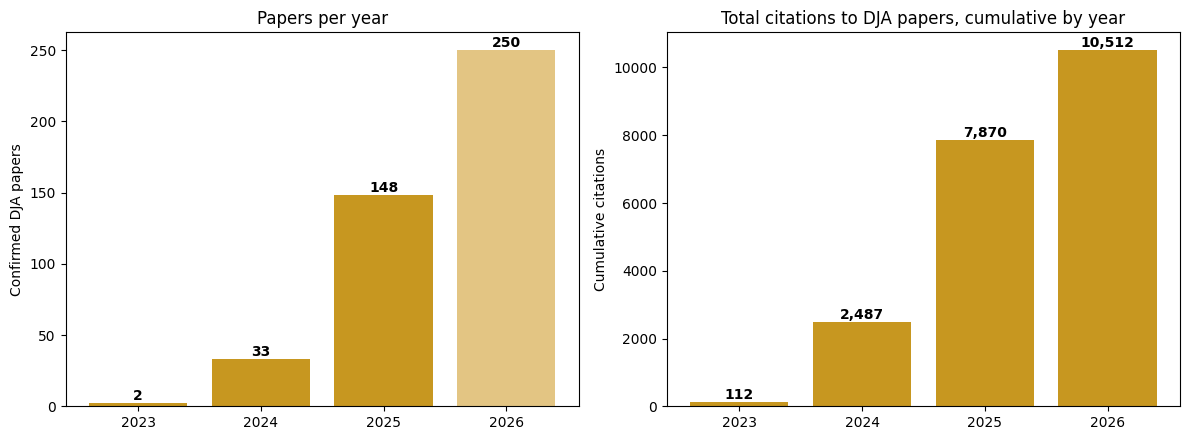

In [4]:
by_year = df_clean.dropna(subset=["year"]).groupby("year").size().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
colors = ["#c79720" if y < by_year.index.max() else "#e3c583" for y in by_year.index]
ax.bar(by_year.index.astype(int).astype(str), by_year.values, color=colors)
for x, v in enumerate(by_year.values):
    ax.text(x, v, f"{v}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Confirmed DJA papers")
ax.set_title("Papers per year")

# Total citations accrued so far, cumulative by publication year -- always increasing,
# a simple read on DJA's growing citation footprint. No non-DJA comparison here; that
# analysis lives in the private working notebook this example is trimmed from.
cum_citations = (df_clean.dropna(subset=["year"])
                  .groupby("year")["citation_count"].sum().sort_index().cumsum())

ax = axes[1]
ax.bar(cum_citations.index.astype(int).astype(str), cum_citations.values, color="#c79720")
for x, v in enumerate(cum_citations.values):
    ax.text(x, v, f"{v:,.0f}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Cumulative citations")
ax.set_title("Total citations to DJA papers, cumulative by year")

plt.tight_layout()
plt.show()

## 4 · Community reach

Citation counts say a paper got noticed; these numbers are about who is actually
behind the work — see the
[metrics page](https://fmvalentino.github.io/dja-metrics/) for the definitions and
their caveats (ORCID-based author matching, the DAWN-affiliation check as an upper
bound, and so on).

Unique authors across all 433 confirmed DJA papers (all years): 2,003
  (matched by ORCID where ADS has one -- 54% of author entries -- else by surname + matching spelled-out given-name tokens, which can still occasionally over- or under-merge)

Team size, 2023+ galaxy papers: median 16, mean 18.7  (n=428)
Unique first authors (all years): 314
Papers with no Cosmic Dawn Center co-author (upper bound on external adoption): 61%


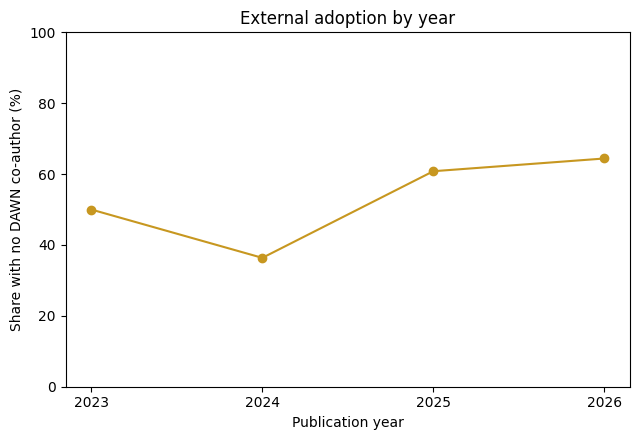

,All confirmed DJA papers
Papers,433.000000
Unique authors,2003.000000
ORCID coverage (%),54.500000
Unique first authors,314.000000
Median authors/paper,16.000000
No DAWN co-author (%),60.969977


In [5]:
df_dja = df_clean[df_clean["galaxy"] & (df_clean["year"] >= CALC_FROM_YEAR)]

# identities/orcid_coverage were already computed in the previous cell (dawn_author needs them too)
n_auth_all = len(set(identities.values()))
n_first_authors = len({identities[(r["doc"]["bibcode"], 0)] for r in clean if r["doc"].get("author")})

print(f"Unique authors across all {len(df_clean)} confirmed DJA papers (all years): {n_auth_all:,}")
print(f"  (matched by ORCID where ADS has one -- {100 * orcid_coverage:.0f}% of author entries -- "
      "else by surname + matching spelled-out given-name tokens, which can still "
      "occasionally over- or under-merge)")

team = df_dja["n_authors"]
print(f"\nTeam size, {CALC_FROM_YEAR}+ galaxy papers: median {team.median():.0f}, "
      f"mean {team.mean():.1f}  (n={len(team)})")

print(f"Unique first authors (all years): {n_first_authors}")

ext_all = 1 - df_clean["dawn_author"].mean()
print(f"Papers with no Cosmic Dawn Center co-author (upper bound on external adoption): "
      f"{100 * ext_all:.0f}%")

ext_by_year = df_clean.groupby("year")["dawn_author"].apply(lambda s: 100 * (1 - s.mean()))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(ext_by_year.index, ext_by_year.values, marker="o", color="#c79720")
ax.set_xticks(ext_by_year.index.astype(int))
ax.set_ylim(0, 100)
ax.set_xlabel("Publication year"); ax.set_ylabel("Share with no DAWN co-author (%)")
ax.set_title("External adoption by year")
plt.tight_layout()
plt.show()

community = pd.Series({
    "Papers":                len(df_clean),
    "Unique authors":        n_auth_all,
    "ORCID coverage (%)":    round(100 * orcid_coverage, 1),
    "Unique first authors":  n_first_authors,
    "Median authors/paper":  df_clean["n_authors"].median(),
    "No DAWN co-author (%)": 100 * ext_all,
}, name="All confirmed DJA papers")
display(community.to_frame())

## 5 · Export

Same two CSVs (`dja_papers_clean.csv`, `dja_papers_contaminants.csv`) and the
community summary the metrics page's own pipeline produces, written to `output/`.

In [6]:
df_clean.to_csv(f"{OUTPUT_DIR}/dja_papers_clean.csv", index=False)
df_contaminants.to_csv(f"{OUTPUT_DIR}/dja_papers_contaminants.csv", index=False)
community.to_frame().to_csv(f"{OUTPUT_DIR}/dja_community_reach.csv")
print(f"Wrote {OUTPUT_DIR}/dja_papers_clean.csv, dja_papers_contaminants.csv, dja_community_reach.csv")

Wrote output/dja_papers_clean.csv, dja_papers_contaminants.csv, dja_community_reach.csv
